In [1]:
!pip install feature_engine imbalanced_learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from feature_engine.encoding import WoEEncoder, RareLabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
column_dtypes = {
    'cc_num':'object',
    'zip': 'object'
}

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
path = 'DataSet/fraudtrain.csv'
DataFeed = pd.read_csv(path, index_col=0, dtype=column_dtypes, parse_dates=['trans_date_trans_time', 'dob'])

C:\ProgramData\Anaconda3\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


In [6]:
DataFeed.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
DataFeed.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  object        
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  object        
 12  lat                    12966

In [8]:
columns = ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'gender', 'lat', 'long', 'job', 'dob','merch_lat', 'merch_long', 'is_fraud']


In [9]:
DataFeed['age'] = np.rint((pd.to_datetime('now') - DataFeed['dob']) / np.timedelta64(1, 'Y'))

In [10]:
DataFeed.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,34.0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,43.0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,60.0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,55.0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,36.0


<AxesSubplot:title={'center':'Number of frauds by categories'}, xlabel='category', ylabel='cc_num'>

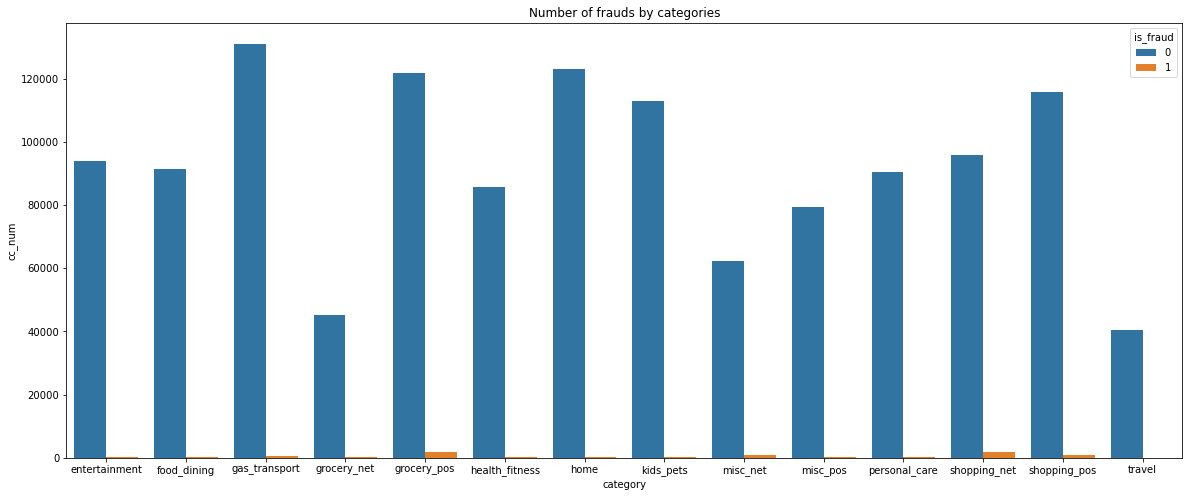

In [11]:
plt.figure(figsize=(20,8))
plt.title('Number of frauds by categories')
sns.barplot(x="category", y='cc_num' ,hue="is_fraud", data=DataFeed.groupby(['category','is_fraud']).agg({'cc_num':'count'}).reset_index())

<AxesSubplot:title={'center':'Number of frauds by the average amount of money spent'}, xlabel='is_fraud', ylabel='amt'>

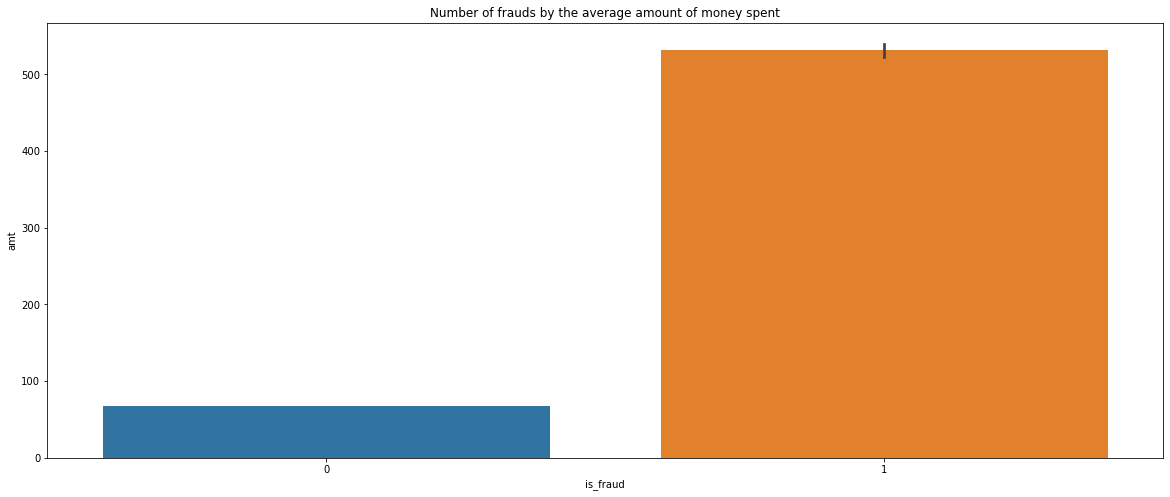

In [12]:
plt.figure(figsize=(20,8))
plt.title('Number of frauds by the average amount of money spent')
sns.barplot(x="is_fraud", y='amt', data=DataFeed)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


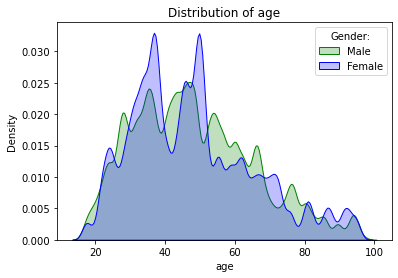

In [13]:
fig, ax = plt.subplots()
sns.distplot(DataFeed.loc[DataFeed.gender=='M', 'age'].dropna(),hist=False, color='green', kde_kws={"shade": True},ax=ax, label='Male')
sns.distplot(DataFeed.loc[DataFeed.gender=='F', 'age'].dropna(),hist=False, color='blue',kde_kws={"shade": True},ax=ax, label='Female')
ax.set_title('Distribution of age')
ax.legend(title='Gender:')

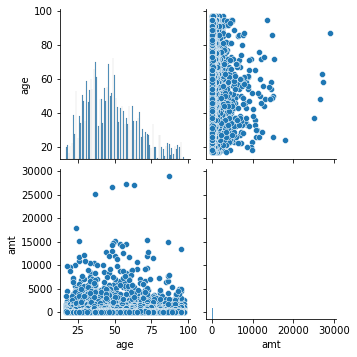

In [14]:
sns.pairplot(DataFeed[['age', 'amt']])

In [15]:
DataFeed.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,34.0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,43.0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,60.0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,55.0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,36.0


In [16]:
DataFeed['is_fraud']

0          0
1          0
2          0
3          0
4          0
          ..
1296670    0
1296671    0
1296672    0
1296673    0
1296674    0
Name: is_fraud, Length: 1296675, dtype: int64

In [17]:
DataFeed.describe()

,amt,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,age
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,7.035104e+01,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,4.813864e+01
std,1.603160e+02,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,1.740110e+01
min,1.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1.700000e+01
25%,9.650000e+00,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,3.500000e+01
50%,4.752000e+01,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,4.600000e+01
75%,8.314000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,5.900000e+01
max,2.894890e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,9.700000e+01


In [18]:
ColumnFeatures = ['category', 'amt', 'gender', 'lat', 'long', 'job', 'age','merch_lat', 'merch_long', 'is_fraud']


In [19]:
X = DataFeed.copy()[ColumnFeatures]
y = X.pop('is_fraud')

In [20]:
y.value_counts()

F    709863
M    586812
Name: gender, dtype: int64

In [21]:
X.head()

,category,amt,lat,long,job,age,merch_lat,merch_long,is_fraud
0,misc_net,4.97,36.0788,-81.1781,"Psychologist, counselling",34.0,36.011293,-82.048315,0
1,grocery_pos,107.23,48.8878,-118.2105,Special educational needs teacher,43.0,49.159047,-118.186462,0
2,entertainment,220.11,42.1808,-112.2620,Nature conservation officer,60.0,43.150704,-112.154481,0
3,gas_transport,45.00,46.2306,-112.1138,Patent attorney,55.0,47.034331,-112.561071,0
4,misc_pos,41.96,38.4207,-79.4629,Dance movement psychotherapist,36.0,38.674999,-78.632459,0


In [22]:
rare_encoder = RareLabelEncoder(tol=0.005, n_categories=2, variables=['category', 'gender','job'])
X_encoded = rare_encoder.fit_transform(X)
woe_encoder = WoEEncoder(variables=['category', 'gender','job'])
woe_encoder.fit(X_encoded , y)

KeyError: "['gender'] not in index"

In [ ]:
def transform_X(X):
    X_encoded = rare_encoder.transform(X)
    return woe_encoder.transform(X_encoded)

In [ ]:
woe_encoder.encoder_dict_

In [ ]:
transform_X(X)

# IV. Prepare data for modeling

In [ ]:
# Because there are not many records labeled 1, I will undersample to balance the data and reduce training time
rus = RandomUnderSampler(random_state=42)
shit = transform_X(X)
X_resample, y_resample = rus.fit_resample(transform_X(X), y)

# V. Train model

In [ ]:
parameters = {'max_depth': [3, 5, 10],
              'min_samples_split': [2, 5, 10]}
rf = RandomForestClassifier()
clf = GridSearchCV(rf, parameters,scoring='accuracy',cv=5)
clf.fit(shit, y)
clf.best_params_

In [ ]:
# Hello World

# VI. Test and plot results

In [ ]:
test_path = 'Dataset/fraudTest.csv'
DataFeed_test = pd.read_csv(path, index_col=0, dtype=column_dtypes, parse_dates=['trans_date_trans_time', 'dob'])
DataFeed_test['age'] = np.rint((pd.to_datetime('now') - DataFeed['dob']) / np.timedelta64(1, 'Y'))
X_test = DataFeed_test.copy()[features_cols]
y_test = X_test.pop('is_fraud')
X_test = transform_X(X_test)
X_test_resample, y_test_resample = rus.fit_resample(X_test, y_test)

In [ ]:
y_test_resample.value_counts()

In [ ]:
svm = SVC()
svm.fit(X_resample, y_resample)
svm_yhat = svm.predict(X_test_resample)


In [ ]:
y_pre = svm.predict(X_test_resample)
print(classification_report(y_test_resample, y_pre))
pd.crosstab(Y_Test_Data, ModelPrediction, rownames = ['Actual'], colnames =['Predicted'])


In [ ]:
svm.score(X_test_resample, y_test_resample)

In [ ]:
clf.score(X_test_resample, y_test_resample)

In [ ]:
from sklearn.metrics import classification_report
y_pred = clf.predict(X_test_resample)

In [ ]:
print(classification_report(y_test_resample, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_test_resample, y_pred)

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, 
            fmt='.2%', cmap='Blues')

In [ ]:
from sklearn import metrics

In [ ]:
#define metrics
y_pred_proba = clf.predict_proba(X_test_resample)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test_resample,  y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)
plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic example")
plt.legend(loc="lower right")
plt.show()